# Welcome to Colab!

In [ ]:
# File 1

from google.colab import files
uploaded = files.upload()

Saving canada_per_capita_income.csv to canada_per_capita_income (1).csv


In [ ]:
# Load file 1

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

df = pd.read_csv('canada_per_capita_income.csv')
df.head()

,year,per capita income (US$)
0,1970,3399.299037
1,1971,3768.297935
2,1972,4251.175484
3,1973,4804.463248
4,1974,5576.514583


In [ ]:
# Check for missing values

print("\nMissing Values:\n", df.isnull().sum())


Missing Values:
 year                       0
per capita income (US$)    0
dtype: int64


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(



Predicted Per Capita Income for 2020: 41288.69409441762


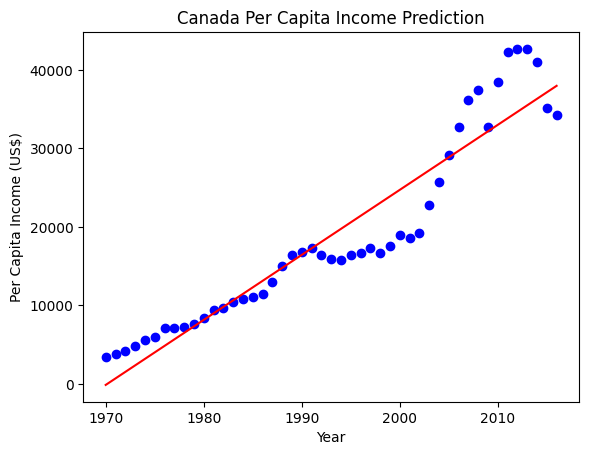

In [ ]:
# Define variables and create Linear Regression model

X = df[['year']]
y = df['per capita income (US$)']

model = LinearRegression()
model.fit(X, y)

prediction_2020 = model.predict([[2020]])
print("\nPredicted Per Capita Income for 2020:", prediction_2020[0])

plt.scatter(X, y, color='blue')
plt.plot(X, model.predict(X), color='red')
plt.xlabel("Year")
plt.ylabel("Per Capita Income (US$)")
plt.title("Canada Per Capita Income Prediction")
plt.show()

In [ ]:
# File 2

from google.colab import files
uploaded = files.upload()

Saving salary.csv to salary.csv


In [ ]:
# Load File 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

df = pd.read_csv('salary.csv')
df.head()

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


In [ ]:
# Check for missing values

print("\nMissing Values:\n", df.isnull().sum())


Missing Values:
 YearsExperience    2
Salary             0
dtype: int64



Model Evaluation:
R2 Score: 0.9152746259911385
Mean Squared Error: 43277377.362307236

Predicted Salary for 12 years of experience: 139500.5314101859


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


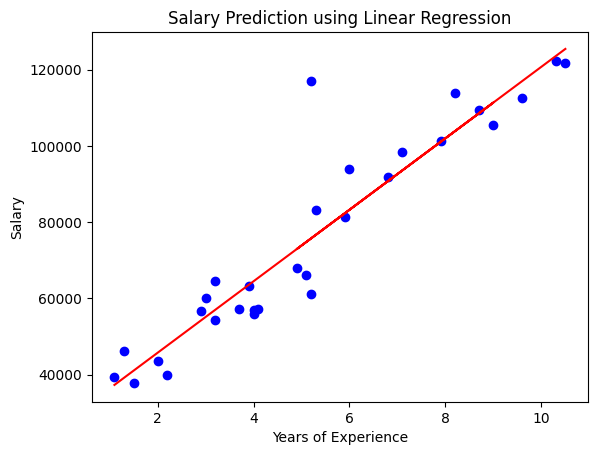

In [ ]:
# Define variables and create Linear Regression model

X = df[['YearsExperience']]
y = df['Salary']

# Fill NaN values in 'YearsExperience' with the mean
X = X.fillna(X.mean())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\nModel Evaluation:")
print("R2 Score:", r2_score(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))

salary_12_years = model.predict([[12]])
print("\nPredicted Salary for 12 years of experience:", salary_12_years[0])

plt.scatter(X, y, color='blue')
plt.plot(X, model.predict(X), color='red')
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Salary Prediction using Linear Regression")
plt.show()

In [1]:
# File 3

from google.colab import files
uploaded = files.upload()

Saving hiring.csv to hiring.csv


In [2]:
# Load File 3

import pandas as pd

df_hiring = pd.read_csv('hiring.csv')
df_hiring.head()

,experience,test_score(out of 10),interview_score(out of 10),salary($)
0,NaN,8.0,9,50000
1,NaN,8.0,6,45000
2,five,6.0,7,60000
3,two,10.0,10,65000
4,seven,9.0,6,70000


In [3]:
# Experience Mapping

experience_mapping = {
    'one': 1, 'two': 2, 'three': 3, 'four': 4, 'five': 5,
    'six': 6, 'seven': 7, 'eight': 8, 'nine': 9, 'ten': 10,
    'eleven': 11
}
df_hiring['experience'] = df_hiring['experience'].replace(experience_mapping)
df_hiring['experience'] = pd.to_numeric(df_hiring['experience'], errors='coerce')
df_hiring.head()

/tmp/ipython-input-2043145291.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_hiring['experience'] = df_hiring['experience'].replace(experience_mapping)


,experience,test_score(out of 10),interview_score(out of 10),salary($)
0,NaN,8.0,9,50000
1,NaN,8.0,6,45000
2,5.0,6.0,7,60000
3,2.0,10.0,10,65000
4,7.0,9.0,6,70000


In [4]:
# Handling Missing Values

experience_mean = df_hiring['experience'].mean()
df_hiring['experience'] = df_hiring['experience'].fillna(experience_mean)

print("\nUpdated DataFrame after filling missing experience values:")
df_hiring.head()
print("\nMissing Values after imputation:\n", df_hiring.isnull().sum())


Updated DataFrame after filling missing experience values:

Missing Values after imputation:
 experience                    0
test_score(out of 10)         1
interview_score(out of 10)    0
salary($)                     0
dtype: int64


In [5]:
test_score_mean = df_hiring['test_score(out of 10)'].mean()
df_hiring['test_score(out of 10)'] = df_hiring['test_score(out of 10)'].fillna(test_score_mean)

print("\nUpdated DataFrame after filling missing test_score values:")
df_hiring.head()
print("\nMissing Values after imputation:", df_hiring.isnull().sum())



Updated DataFrame after filling missing test_score values:

Missing Values after imputation: experience                    0
test_score(out of 10)         0
interview_score(out of 10)    0
salary($)                     0
dtype: int64


In [6]:
# Assigning Variables

X = df_hiring[['experience', 'test_score(out of 10)', 'interview_score(out of 10)']]
y = df_hiring['salary($)']

print("Features (X):")
print(X.head())
print("\nTarget (y):")
print(y.head())

Features (X):
   experience  test_score(out of 10)  interview_score(out of 10)
0    6.333333                    8.0                           9
1    6.333333                    8.0                           6
2    5.000000                    6.0                           7
3    2.000000                   10.0                          10
4    7.000000                    9.0                           6

Target (y):
0    50000
1    45000
2    60000
3    65000
4    70000
Name: salary($), dtype: int64


In [7]:
# Training Model

from sklearn.linear_model import LinearRegression

model_hiring = LinearRegression()
model_hiring.fit(X, y)

print("Multiple Linear Regression model trained successfully.")

Multiple Linear Regression model trained successfully.


In [8]:
# Predicting Salaries

new_candidates = pd.DataFrame({
    'experience': [2, 12],
    'test_score(out of 10)': [9, 10],
    'interview_score(out of 10)': [6, 10]
})

predicted_salaries = model_hiring.predict(new_candidates)

print("\nPredicted Salaries for New Candidates:")
for i, salary in enumerate(predicted_salaries):
    print(f"Candidate {i+1} Salary: ${salary:.2f}")


Predicted Salaries for New Candidates:
Candidate 1 Salary: $47738.89
Candidate 2 Salary: $86424.67


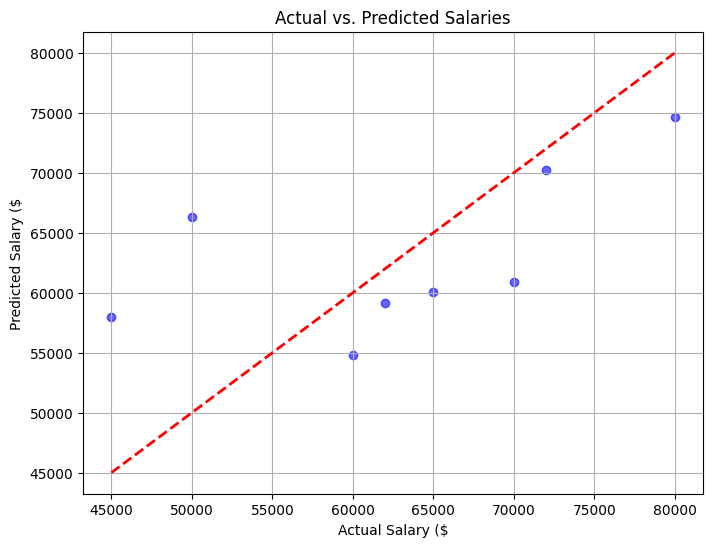


R2 Score on training data: 0.34
Mean Squared Error on training data: 75981042.01


In [9]:
# Plotting Multiple Linear Regression Graph

import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error

y_pred_actual = model_hiring.predict(X)

plt.figure(figsize=(8, 6))
plt.scatter(y, y_pred_actual, color='blue', alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2) # Line for perfect prediction
plt.xlabel("Actual Salary ($")
plt.ylabel("Predicted Salary ($")
plt.title("Actual vs. Predicted Salaries")
plt.grid(True)
plt.show()

r2 = r2_score(y, y_pred_actual)
mse = mean_squared_error(y, y_pred_actual)

print(f"\nR2 Score on training data: {r2:.2f}")
print(f"Mean Squared Error on training data: {mse:.2f}")

In [10]:
# File 4

from google.colab import files
uploaded = files.upload()

Saving 1000_Companies.csv to 1000_Companies.csv


In [11]:
# Load File 4

import pandas as pd

df_companies = pd.read_csv('/content/1000_Companies.csv')
df_companies.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [12]:
# One-Hot Encoding

states_encoded = pd.get_dummies(df_companies['State'], drop_first=True, dtype=int)
df_companies = pd.concat([df_companies, states_encoded], axis=1)
df_companies = df_companies.drop('State', axis=1)
df_companies.head()

,R&D Spend,Administration,Marketing Spend,Profit,Florida,New York
0,165349.20,136897.80,471784.10,192261.83,0,1
1,162597.70,151377.59,443898.53,191792.06,0,0
2,153441.51,101145.55,407934.54,191050.39,1,0
3,144372.41,118671.85,383199.62,182901.99,0,1
4,142107.34,91391.77,366168.42,166187.94,1,0


In [13]:
# Assign Variables (Features)

X = df_companies[['R&D Spend', 'Administration', 'Marketing Spend', 'Florida', 'New York']]
y = df_companies['Profit']

print("Features (X):")
print(X.head())
print("\nTarget (y):")
print(y.head())

Features (X):
   R&D Spend  Administration  Marketing Spend  Florida  New York
0  165349.20       136897.80        471784.10        0         1
1  162597.70       151377.59        443898.53        0         0
2  153441.51       101145.55        407934.54        1         0
3  144372.41       118671.85        383199.62        0         1
4  142107.34        91391.77        366168.42        1         0

Target (y):
0    192261.83
1    191792.06
2    191050.39
3    182901.99
4    166187.94
Name: Profit, dtype: float64


In [14]:
# Train the model

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (800, 5)
X_test shape: (200, 5)
y_train shape: (800,)
y_test shape: (200,)


In [15]:
from sklearn.linear_model import LinearRegression

model_companies = LinearRegression()
model_companies.fit(X_train, y_train)

print("Multiple Linear Regression model for companies trained successfully.")

Multiple Linear Regression model for companies trained successfully.


In [16]:
# Error

from sklearn.metrics import r2_score, mean_squared_error

y_pred = model_companies.predict(X_test)

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"R-squared score: {r2:.2f}")
print(f"Mean Squared Error: {mse:.2f}")

R-squared score: 0.91
Mean Squared Error: 192148061.82


In [17]:
# New Candidate

new_candidate_data = pd.DataFrame({
    'R&D Spend': [91694.48],
    'Administration': [515841.3],
    'Marketing Spend': [11931.24],
    'State': ['Florida']
})

# Apply one-hot encoding to the 'State' column
states_encoded_new = pd.get_dummies(new_candidate_data['State'], drop_first=True, dtype=int)

# Concatenate the one-hot encoded state columns with the rest of the new_candidate_data DataFrame
new_candidate_data = pd.concat([new_candidate_data, states_encoded_new], axis=1)

# Drop the original 'State' column
new_candidate_data = new_candidate_data.drop('State', axis=1)

# Ensure columns in new_candidate_data match the columns in X
# Get the column names from the original training features X
feature_columns = X.columns

# Add missing columns to new_candidate_data and fill with 0, then reorder
for col in feature_columns:
    if col not in new_candidate_data.columns:
        new_candidate_data[col] = 0

new_candidate_data = new_candidate_data[feature_columns]

print("Prepared New Candidate Data:")
print(new_candidate_data)

Prepared New Candidate Data:
   R&D Spend  Administration  Marketing Spend  Florida  New York
0   91694.48        515841.3         11931.24        0         0


In [20]:
# Profit Prediction

predicted_profit = model_companies.predict(new_candidate_data)

print(f"Predicted Profit for New Candidate: ${predicted_profit[0]:.2f}")

Predicted Profit for New Candidate: $434037.12


R-squared score on test data: 0.91
Mean Squared Error on test data: 192148061.82


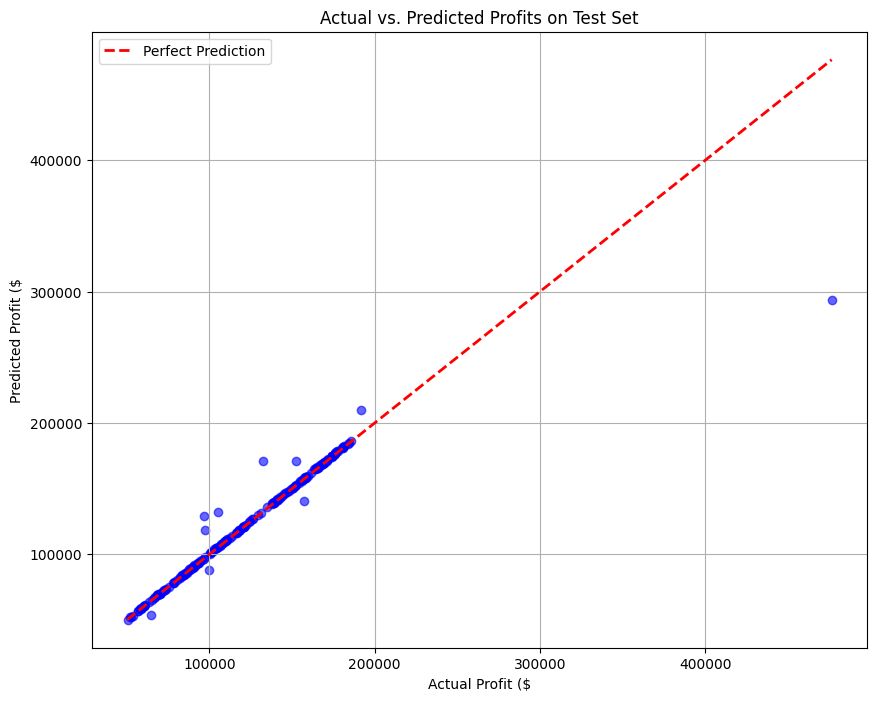

In [19]:
# Visualization

import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error

# 1. Use the trained model_companies to predict y values for the X_test data.
y_pred_test = model_companies.predict(X_test)

# 2. Calculate the R-squared score
r2 = r2_score(y_test, y_pred_test)
print(f"R-squared score on test data: {r2:.2f}")

# 3. Calculate the Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred_test)
print(f"Mean Squared Error on test data: {mse:.2f}")

# 4. Create a scatter plot
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred_test, color='blue', alpha=0.6)

# 5. Add a line representing perfect predictions
min_val = min(y_test.min(), y_pred_test.min())
max_val = max(y_test.max(), y_pred_test.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')

# 6. Label the x-axis and y-axis
plt.xlabel("Actual Profit ($")
plt.ylabel("Predicted Profit ($")

# 7. Add a title to the plot
plt.title("Actual vs. Predicted Profits on Test Set")

# 8. Add a grid to the plot
plt.grid(True)

# Add a legend
plt.legend()

# 9. Display the plot
plt.show()